# **KUIS 2 SBP**

NERVALINA ADZRA NORA AQILLA

3C SIB

**UPLOAD FILE**

In [ ]:
# Upload file dari lokal
from google.colab import files
uploaded = files.upload()

Saving Data_Polis.csv to Data_Polis.csv
Saving Data_Klaim.csv to Data_Klaim.csv


**IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**LOAD & PREPROCESSING DATA**

In [23]:
polis = pd.read_csv('Data_Polis.csv')
klaim = pd.read_csv('Data_Klaim.csv')

# rapikan kolom
polis.columns = polis.columns.str.strip().str.lower()
klaim.columns = klaim.columns.str.strip().str.lower()

# merge pakai nomor polis (dari dataset kamu)
data = pd.merge(polis, klaim, on='nomor polis')

data.head()

,nomor polis,plan code,gender,tanggal lahir,tanggal efektif polis,domisili,claim id,reimburse/cashless,inpatient/outpatient,icd diagnosis,icd description,status klaim,tanggal pembayaran klaim,tanggal pasien masuk rs,tanggal pasien keluar rs,nominal klaim yang disetujui,nominal biaya rs yang terjadi,lokasi rs
0,POL-0003,M-001,M,19790821,20160808,JAKARTA,C-3535-M,C,IP,S83.2,"TEAR OF MENISCUS, CURRENT",PAID,2024-10-31,2024-09-09,2024-09-10,14138163.0,14138163.0,Indonesia
1,POL-0006,M-001,F,19551127,20160628,JAKARTA,C-4498-M,C,IP,S46.0,INJURY OF MUSCLE(S) AND TENDON(S) OF THE ROTAT...,PAID,2024-11-13,2024-08-16,2024-08-22,117940836.0,120388776.0,Indonesia
2,POL-0006,M-001,F,19551127,20160628,JAKARTA,C-4499-M,C,IP,T84.7,INFECTION AND INFLAMMATORY REACTION DUE TO OTH...,PAID,2024-12-13,2024-10-23,2024-10-24,60671660.0,61800880.0,Indonesia
3,POL-0010,M-001,F,19570605,20170908,JAKARTA,C-3447-M,R,IP,K31.7,POLYP OF STOMACH AND DUODENUM,PAID,2024-02-27,2024-01-19,2024-01-19,1723747.0,1723747.0,Singapore
4,POL-0010,M-001,F,19570605,20170908,JAKARTA,C-3448-M,R,IP,K31.7,POLYP OF STOMACH AND DUODENUM,PAID,2024-02-27,2024-01-18,2024-01-18,63251531.0,63251531.0,Singapore


**FEATURE ENGINEERING (5 KRITERIA)**

In [24]:
# convert tanggal
data['tanggal efektif polis'] = pd.to_datetime(data['tanggal efektif polis'])
data['tanggal pasien masuk rs'] = pd.to_datetime(data['tanggal pasien masuk rs'])
data['tanggal pasien keluar rs'] = pd.to_datetime(data['tanggal pasien keluar rs'])
data['tanggal lahir'] = pd.to_datetime(data['tanggal lahir'])

# 1. Lama Polis
data['lama_polis'] = (pd.Timestamp.now() - data['tanggal efektif polis']).dt.days

# 2. Durasi Rawat
data['durasi_rawat'] = (data['tanggal pasien keluar rs'] - data['tanggal pasien masuk rs']).dt.days

# 3. Klaim
data['klaim'] = data['nominal klaim yang disetujui']

# 4. Selisih Biaya RS
data['selisih_biaya'] = data['nominal biaya rs yang terjadi'] - data['nominal klaim yang disetujui']

# 5. Umur
data['umur'] = (pd.Timestamp.now() - data['tanggal lahir']).dt.days // 365

# hapus data kosong
data = data.dropna()

In [25]:
criteria = ['klaim', 'lama_polis', 'durasi_rawat', 'selisih_biaya', 'umur']

X = data[criteria].values

# jenis kriteria (0=cost, 1=benefit)
jenis = [0, 1, 0, 0, 0]

# bobot
bobot = np.array([0.3, 0.25, 0.15, 0.15, 0.15])

**SAW**

NORMALISASI

In [26]:
R = np.zeros_like(X, dtype=float)

for j in range(len(criteria)):
    if jenis[j] == 1:
        R[:, j] = X[:, j] / np.max(X[:, j])
    else:
        R[:, j] = np.min(X[:, j]) / X[:, j]

V_saw = np.dot(R, bobot)
data['SAW'] = V_saw

/tmp/ipykernel_4274/3167436595.py:7: RuntimeWarning: invalid value encountered in divide
  R[:, j] = np.min(X[:, j]) / X[:, j]
/tmp/ipykernel_4274/3167436595.py:7: RuntimeWarning: divide by zero encountered in divide
  R[:, j] = np.min(X[:, j]) / X[:, j]


RANKING SAW

In [27]:
data['Rank_SAW'] = data['SAW'].rank(ascending=False)
data_saw = data.sort_values(by='SAW', ascending=False)

VISUALISASI SAW

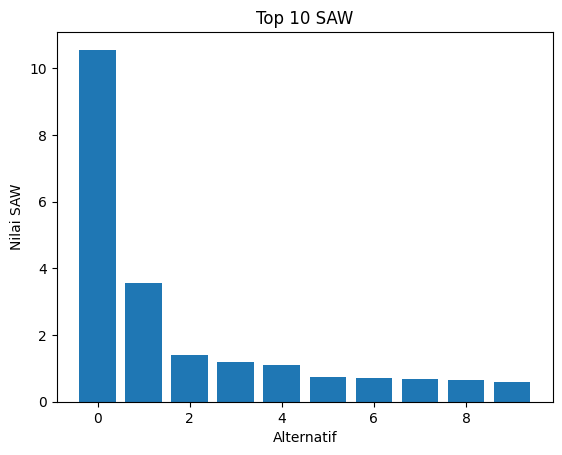

In [28]:
plt.figure()
plt.bar(range(10), data_saw['SAW'].head(10))
plt.title('Top 10 SAW')
plt.xlabel('Alternatif')
plt.ylabel('Nilai SAW')
plt.show()

**EDAS**

PERHITUNGAN

In [29]:
avg = np.mean(X, axis=0)

PDA = np.zeros_like(X)
NDA = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        if jenis[j] == 1:
            PDA[i,j] = max(0, (X[i,j] - avg[j]) / avg[j])
            NDA[i,j] = max(0, (avg[j] - X[i,j]) / avg[j])
        else:
            PDA[i,j] = max(0, (avg[j] - X[i,j]) / avg[j])
            NDA[i,j] = max(0, (X[i,j] - avg[j]) / avg[j])

NILAI EDAS

In [30]:
SP = np.dot(PDA, bobot)
SN = np.dot(NDA, bobot)

NSP = SP / np.max(SP)
NSN = 1 - (SN / np.max(SN))

AS = (NSP + NSN) / 2

data['EDAS'] = AS

RANKING EDAS

In [31]:
data['Rank_EDAS'] = data['EDAS'].rank(ascending=False)
data_edas = data.sort_values(by='EDAS', ascending=False)

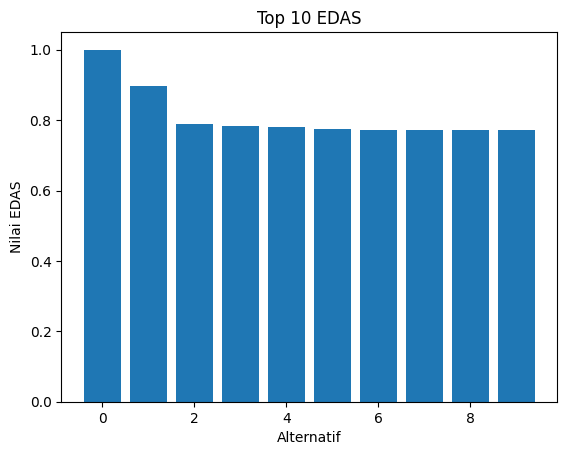

In [32]:
plt.figure()
plt.bar(range(10), data_edas['EDAS'].head(10))
plt.title('Top 10 EDAS')
plt.xlabel('Alternatif')
plt.ylabel('Nilai EDAS')
plt.show()

**TOPSIS**

In [33]:
norm = np.sqrt((X**2).sum(axis=0))
R_topsis = X / norm

Y = R_topsis * bobot

A_plus = np.max(Y, axis=0)
A_minus = np.min(Y, axis=0)

D_plus = np.sqrt(((Y - A_plus)**2).sum(axis=1))
D_minus = np.sqrt(((Y - A_minus)**2).sum(axis=1))

V_topsis = D_minus / (D_plus + D_minus)

data['TOPSIS'] = V_topsis
data['Rank_TOPSIS'] = data['TOPSIS'].rank(ascending=False)

**PERBANDINGAN**

In [34]:
compare = data[['Rank_SAW','Rank_EDAS']].copy()
compare = compare.sort_values(by='Rank_SAW')

compare['Urutan'] = range(1, len(compare)+1)
compare.head(10)

,Rank_SAW,Rank_EDAS,Urutan
1032,1.0,3916.0,1
808,2.0,2443.0,2
1076,3.0,3476.0,3
3074,4.0,3403.0,4
3849,5.0,3236.0,5
197,6.0,2380.0,6
979,7.0,2111.0,7
4107,8.0,2033.0,8
4467,9.0,1710.0,9
139,10.0,2.0,10


**HITUNG KEMIRIPAN**

In [35]:
same = sum(compare['Rank_SAW'] == compare['Rank_EDAS'])
total = len(compare)

print("Sama:", same)
print("Berbeda:", total - same)
print("Persentase Sama:", (same/total)*100)

Sama: 0
Berbeda: 4551
Persentase Sama: 0.0


**VISUALISASI PERBANDINGAN**

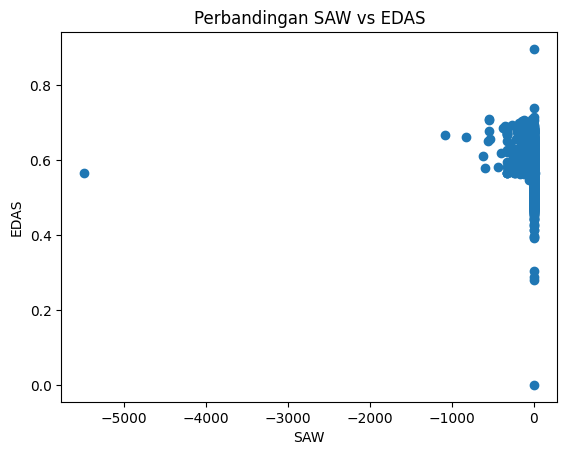

In [36]:
plt.figure()
plt.scatter(data['SAW'], data['EDAS'])
plt.title('Perbandingan SAW vs EDAS')
plt.xlabel('SAW')
plt.ylabel('EDAS')
plt.show()

In [37]:
data.to_csv('hasil_akhir.csv', index=False)

from google.colab import files
files.download('hasil_akhir.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>